https://www.kaggle.com/code/modeh7/final-solution-ncaa-2025/notebook#%3C%3C--Hardest-difficulty-features--%3E%3E

https://www.kaggle.com/competitions/march-machine-learning-mania-2025/writeups/aziel888-5th-place-solution

In [68]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c march-machine-learning-mania-2026
!unzip /content/march-machine-learning-mania-2026.zip
!rm /content/march-machine-learning-mania-2026.zip

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  0% 0.00/34.3M [00:00<?, ?B/s]
100% 34.3M/34.3M [00:00<00:00, 1.16GB/s]
Archive:  /content/march-machine-learning-mania-2026.zip
replace Cities.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [69]:
%%capture
# !pip install autogluon.tabular[all]
!pip install optuna

## Import Packages

In [70]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, GammaRegressor, Ridge
from sklearn.metrics import make_scorer, mean_squared_error, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# from keras_tuner import HyperModel
# from keras_tuner import RandomSearch
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras import layers, models

from sklearn.feature_selection import f_classif
from sklearn.metrics import brier_score_loss
from tqdm import tqdm

# from autogluon.tabular import TabularDataset, TabularPredictor

## Load Data

In [71]:
DATA_PATH = ""

# Regular season compact
m_reg = pd.read_csv(DATA_PATH + "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_PATH + "WRegularSeasonCompactResults.csv")

# Tournament compact
m_tour = pd.read_csv(DATA_PATH + "MNCAATourneyCompactResults.csv")
w_tour = pd.read_csv(DATA_PATH + "WNCAATourneyCompactResults.csv")

# Seeds
m_seeds = pd.read_csv(DATA_PATH + "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_PATH + "WNCAATourneySeeds.csv")

print("Men Regular:", m_reg.shape)
print("Women Regular:", w_reg.shape)
print("Men Tour:", m_tour.shape)
print("Women Tour:", w_tour.shape)

Men Regular: (196823, 8)
Women Regular: (140825, 8)
Men Tour: (2585, 8)
Women Tour: (1717, 8)


In [72]:
# Combine men and women
m_reg["Gender"] = 1
w_reg["Gender"] = 0
m_tour["Gender"] = 1
w_tour["Gender"] = 0

m_seeds["Gender"] = 1
w_seeds["Gender"] = 0

reg = pd.concat([m_reg, w_reg], ignore_index=True)
tour = pd.concat([m_tour, w_tour], ignore_index=True)
seeds = pd.concat([m_seeds, w_seeds], ignore_index=True)

print("Combined Regular:", reg.shape)
print("Combined Tour:", tour.shape)

Combined Regular: (337648, 9)
Combined Tour: (4302, 9)


In [73]:
reg["Margin"] = reg["WScore"] - reg["LScore"]

# Winning rows
win_df = reg[[
    "Season","DayNum","WTeamID","WScore",
    "LTeamID","LScore","WLoc","Gender"
]].copy()

win_df.columns = [
    "Season","DayNum","TeamID","TeamScore",
    "OppID","OppScore","Loc","Gender"
]

win_df["Win"] = 1

# Losing rows
loss_df = reg[[
    "Season","DayNum","LTeamID","LScore",
    "WTeamID","WScore","WLoc","Gender"
]].copy()

loss_df.columns = [
    "Season","DayNum","TeamID","TeamScore",
    "OppID","OppScore","Loc","Gender"
]

loss_df["Win"] = 0

# Flip location
loss_df["Loc"] = loss_df["Loc"].map({"H":"A","A":"H","N":"N"})

team_games = pd.concat([win_df, loss_df], ignore_index=True)

team_games["Margin"] = team_games["TeamScore"] - team_games["OppScore"]

team_games.head()

,Season,DayNum,TeamID,TeamScore,OppID,OppScore,Loc,Gender,Win,Margin
0,1985,20,1228,81,1328,64,N,1,1,17
1,1985,25,1106,77,1354,70,H,1,1,7
2,1985,25,1112,63,1223,56,H,1,1,7
3,1985,25,1165,70,1432,54,H,1,1,16
4,1985,25,1192,86,1447,74,H,1,1,12


In [74]:
# Season Level Stats
season_stats = (
    team_games
    .groupby(["Season","TeamID","Gender"])
    .agg(
        games=("Win","count"),
        win_pct=("Win","mean"),
        avg_score=("TeamScore","mean"),
        avg_allowed=("OppScore","mean"),
        avg_margin=("Margin","mean")
    )
    .reset_index()
)

season_stats.head()

,Season,TeamID,Gender,games,win_pct,avg_score,avg_allowed,avg_margin
0,1985,1102,1,24,0.208333,63.083333,68.875000,-5.791667
1,1985,1103,1,23,0.391304,61.043478,64.086957,-3.043478
2,1985,1104,1,30,0.700000,68.500000,60.700000,7.800000
3,1985,1106,1,24,0.416667,71.625000,75.416667,-3.791667
4,1985,1108,1,25,0.760000,83.000000,75.040000,7.960000


In [75]:
# Add Seed Numbers
seeds["SeedNum"] = seeds["Seed"].str[1:3].astype(int)

seeds.head()

,Season,Seed,TeamID,Gender,SeedNum
0,1985,W01,1207,1,1
1,1985,W02,1210,1,2
2,1985,W03,1228,1,3
3,1985,W04,1260,1,4
4,1985,W05,1374,1,5


In [76]:
df = tour.copy()

df["Team1"] = df[["WTeamID","LTeamID"]].min(axis=1)
df["Team2"] = df[["WTeamID","LTeamID"]].max(axis=1)

df["Target"] = (df["WTeamID"] == df["Team1"]).astype(int)

df = df[["Season","Gender","Team1","Team2","Target"]]

In [77]:
# Create copies with prefixed columns
t1_stats = season_stats.copy()
t2_stats = season_stats.copy()

# Rename only feature columns
feature_cols = ["games","win_pct","avg_score","avg_allowed","avg_margin"]

t1_stats = t1_stats.rename(
    columns={col: f"T1_{col}" for col in feature_cols}
)

t2_stats = t2_stats.rename(
    columns={col: f"T2_{col}" for col in feature_cols}
)


df = df.merge(
    t1_stats,
    left_on=["Season","Team1","Gender"],
    right_on=["Season","TeamID","Gender"],
    how="left"
)

df = df.drop(columns=["TeamID"])

df = df.merge(
    t2_stats,
    left_on=["Season","Team2","Gender"],
    right_on=["Season","TeamID","Gender"],
    how="left"
)

df = df.drop(columns=["TeamID"])

In [78]:
features = [ "win_pct","avg_score","avg_allowed","avg_margin"]

for col in features:
    df[col + "_diff"] = df["T1_" + col] - df["T2_" + col]

In [79]:
def assign_era(season):
    """
    Season refers to tournament year (e.g. 2015 = 2014-15 season)
    """
    if season <= 1990:
        return "GameChangers"
    elif season <= 2018:
        return "PaceUp"
    else:
        return "Modern"

# Apply to tournament dataset
df["Era"] = df["Season"].apply(assign_era)

# OHE
df["Era_PaceUp"] = 0
df["Era_Modern"] = 0
df.loc[df["Era"] == "PaceUp", "Era_PaceUp"] = 1
df.loc[df["Era"] == "Modern", "Era_Modern"] = 1
df = df.drop(columns=["Era"])

In [80]:
df

,Season,Gender,Team1,Team2,Target,T1_games,T1_win_pct,T1_avg_score,T1_avg_allowed,T1_avg_margin,...,T2_win_pct,T2_avg_score,T2_avg_allowed,T2_avg_margin,win_pct_diff,avg_score_diff,avg_allowed_diff,avg_margin_diff,Era_PaceUp,Era_Modern
0,1985,1,1116,1234,1,33,0.636364,65.333333,61.696970,3.636364,...,0.666667,69.733333,59.266667,10.466667,-0.030303,-4.400000,2.430303,-6.830303,0,0
1,1985,1,1120,1345,1,29,0.620690,70.344828,66.655172,3.689655,...,0.680000,69.120000,65.320000,3.800000,-0.059310,1.224828,1.335172,-0.110345,0,0
2,1985,1,1207,1250,1,27,0.925926,75.740741,60.074074,15.666667,...,0.379310,65.758621,70.206897,-4.448276,0.546616,9.982120,-10.132822,20.114943,0,0
3,1985,1,1229,1425,1,27,0.740741,71.592593,65.629630,5.962963,...,0.678571,68.392857,64.607143,3.785714,0.062169,3.199735,1.022487,2.177249,0,0
4,1985,1,1242,1325,1,30,0.766667,76.033333,70.400000,5.633333,...,0.740741,67.555556,63.000000,4.555556,0.025926,8.477778,7.400000,1.077778,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4297,2025,0,3163,3425,1,34,0.911765,80.823529,51.852941,28.970588,...,0.903226,81.451613,59.838710,21.612903,0.008539,-0.628083,-7.985769,7.357685,0,1
4298,2025,0,3395,3400,0,34,0.911765,77.588235,57.294118,20.294118,...,0.911765,78.941176,55.911765,23.029412,0.000000,-1.352941,1.382353,-2.735294,0,1
4299,2025,0,3163,3417,1,34,0.911765,80.823529,51.852941,28.970588,...,0.937500,78.625000,57.656250,20.968750,-0.025735,2.198529,-5.803309,8.001838,0,1
4300,2025,0,3376,3400,1,33,0.909091,80.484848,57.757576,22.727273,...,0.911765,78.941176,55.911765,23.029412,-0.002674,1.543672,1.845811,-0.302139,0,1


## EDA

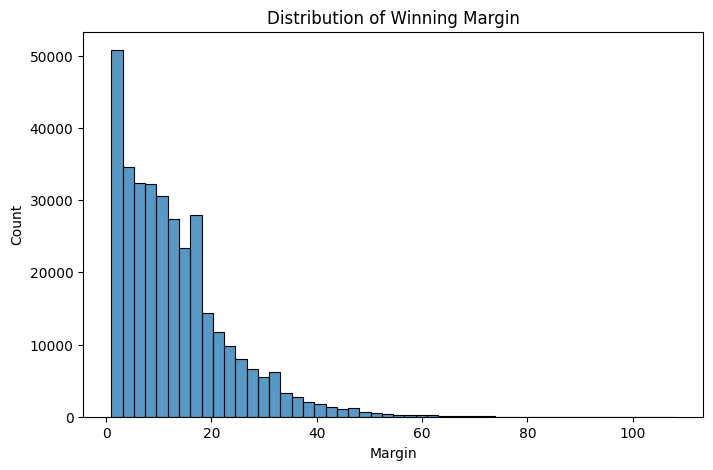

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(reg["Margin"], bins=50)
plt.title("Distribution of Winning Margin")
plt.show()

## HGBG

In [82]:
X_cols = [c for c in df.columns if c.endswith("_diff")] + ["Gender", 'Era_PaceUp',	'Era_Modern']
X_cols

['win_pct_diff',
 'avg_score_diff',
 'avg_allowed_diff',
 'avg_margin_diff',
 'Gender',
 'Era_PaceUp',
 'Era_Modern']

In [83]:
# Years to leave out as validation one at a time
val_years = [2019, 2021, 2022, 2023, 2024, 2025]

brier_scores = []

for val_year in tqdm(val_years, desc="LOSO CV Seasons"):
    # Train on all previous seasons
    train_mask = df["Season"] < val_year
    val_mask   = df["Season"] == val_year

    X_train = df.loc[train_mask, X_cols]
    y_train = df.loc[train_mask, "Target"]

    X_val   = df.loc[val_mask, X_cols]
    y_val   = df.loc[val_mask, "Target"]

    # Fit model
    model = HistGradientBoostingClassifier(
        loss="log_loss",
        # max_depth=6,
        # learning_rate=0.05,
        # max_iter=500,
        random_state=31
    )

    model.fit(X_train, y_train)

    # Predict
    pred_val = model.predict_proba(X_val)[:,1]

    # Compute Brier score
    brier = brier_score_loss(y_val, pred_val)
    brier_scores.append((val_year, brier))

    # Optional: can print per season if you want more verbose
    print(f"Season {val_year}: Brier Score = {brier:.4f}")

# Summary
avg_brier = np.mean([b for _, b in brier_scores])
print("\nAverage Brier score 2019-2025:", round(avg_brier,4))

LOSO CV Seasons:  17%|█▋        | 1/6 [00:00<00:02,  2.24it/s]

Season 2019: Brier Score = 0.2050


LOSO CV Seasons:  33%|███▎      | 2/6 [00:00<00:01,  2.06it/s]

Season 2021: Brier Score = 0.2279


LOSO CV Seasons:  50%|█████     | 3/6 [00:01<00:01,  1.73it/s]

...

Season 2023: Brier Score = 0.2270


LOSO CV Seasons:  83%|████████▎ | 5/6 [00:03<00:00,  1.05it/s]

Season 2024: Brier Score = 0.2176


LOSO CV Seasons: 100%|██████████| 6/6 [00:04<00:00,  1.36it/s]

Season 2025: Brier Score = 0.2064

Average Brier score 2019-2025: 0.22


In [84]:
# --- Final Model Training ---
print("\nTraining final model on all available data (through 2026)...")
X_all = df[X_cols]
y_all = df["Target"]

model = HistGradientBoostingClassifier(
    loss="log_loss",
    random_state=31
)

model.fit(X_all, y_all)


Training final model on all available data (through 2026)...


HistGradientBoostingClassifier(random_state=31)

In [110]:
import pandas as pd
import numpy as np

# Load sample submission
sub = pd.read_csv("/content/SampleSubmissionStage1.csv")

# Parse IDs
sub[["Season","Team1","Team2"]] = sub["ID"].str.split("_", expand=True)
sub["Season"] = sub["Season"].astype(int)
sub["Team1"]  = sub["Team1"].astype(int)
sub["Team2"]  = sub["Team2"].astype(int)
# sub["Gender"] = 1

# Era one-hot (k-1)
sub["Era_PaceUp"]  = (sub["Season"].apply(assign_era) == "PaceUp").astype(int)
sub["Era_Modern"]  = (sub["Season"].apply(assign_era) == "Modern").astype(int)

# Merge T1/T2 stats (diff features)
t1_stats = season_stats.rename(columns={col: f"T1_{col}" for col in feature_cols})
t2_stats = season_stats.rename(columns={col: f"T2_{col}" for col in feature_cols})

sub = sub.merge(
    t1_stats,
    left_on=["Season","Team1"],
    right_on=["Season","TeamID"],
    how="left"
).drop(columns=["TeamID"])

sub = sub.merge(
    t2_stats,
    left_on=["Season","Team2"],
    right_on=["Season","TeamID"],
    how="left"
).drop(columns=["TeamID"])

# Compute diff features
for col in feature_cols:
    sub[f"{col}_diff"] = sub[f"T1_{col}"] - sub[f"T2_{col}"]

sub['Gender'] = sub.filter(like = 'Gender').mean(axis = 1).astype(int)

# Final features for prediction
X_sub = X_cols

# --- Predict using your already trained model ---
sub["Pred"] = model.predict_proba(sub[X_sub])[:,1]  # <--- reuse the CV/final model

In [111]:
sub[["ID","Pred"]].to_csv('/content/drive/MyDrive/Output/sub.csv', index=False)

In [112]:
!kaggle competitions submit -c march-machine-learning-mania-2026 -f /content/drive/MyDrive/Output/sub.csv -m "v2 hgbg"

100% 17.0M/17.0M [00:01<00:00, 10.1MB/s]
Successfully submitted to March Machine Learning Mania 2026

## Save to Github

In [1]:
!git config --global user.email "abishpius@gmail.com"
!git config --global user.name "Abish Pius"

In [2]:
from google.colab import userdata
import requests

token = userdata.get('github')
repo_name = "March-Madness-2026"
username = "abishpius"
message = "Kaggle Competition March Madness 2026"
notebook_name = "Kaggle_March_Madness.ipynb"

headers = {
    "Authorization": f"token {token}",
    "Accept": "application/vnd.github+json"
}

# === CHECK IF REPO EXISTS ===
check_url = f"https://api.github.com/repos/{username}/{repo_name}"
check_resp = requests.get(check_url, headers=headers)

if check_resp.status_code == 200:
    print(f"❌ Repo '{repo_name}' already exists at: https://github.com/{username}/{repo_name}")
else:
    # === CREATE REPO ===
    create_url = "https://api.github.com/user/repos"
    payload = {
        "name": repo_name,
        "auto_init": True,
        "private": False  # change to True if you want a private repo
    }

    create_resp = requests.post(create_url, headers=headers, json=payload)

    if create_resp.status_code == 201:
        print(f"✅ Repo '{repo_name}' created successfully.")

        # === UPDATE README.md ===
        import base64

        update_url = f"https://api.github.com/repos/{username}/{repo_name}/contents/README.md"
        readme_text = ""
        encoded = base64.b64encode(readme_text.encode()).decode()
        update_payload = {
            "message": message,
            "content": encoded,
            "sha": requests.get(update_url, headers=headers).json()["sha"]
        }

        update_resp = requests.put(update_url, headers=headers, json=update_payload)

        if update_resp.status_code == 200 or update_resp.status_code == 201:
            print("✅ README.md updated with custom text.")
        else:
            print("⚠️ Failed to update README.md:", update_resp.json())

    else:
        print("❌ Repo creation failed:", create_resp.json())

✅ Repo 'March-Madness-2026' created successfully.
✅ README.md updated with custom text.


In [3]:
!git clone https://{token}@github.com/{username}/{repo_name}.git

# === MOVE NOTEBOOK ===
import shutil
shutil.copy(f"/content/drive/MyDrive/Colab Notebooks/{notebook_name}", f"/content/{repo_name}/{notebook_name}")

# === COMMIT TO REPO ===
%cd {repo_name}
!git add {notebook_name}
!git commit -m "Primary HGBG Models"
!git push

Cloning into 'March-Madness-2026'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Kaggle_March_Madness.ipynb'